![image-2.png](attachment:image-2.png)
_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Análisis de reducción de dimensionalidad: PCA y t-SNE
## Objetivo General
En este trabajo, se busca que pongas en práctica la aplicación de algoritmos de reducción de dimensionalidad. El objetivo es aplicar técnicas para reducir la dimensionalidad a 2D, graficar los resultados y seleccionar la mejor técnica para los datos. Además, deberás detallar los pasos a seguir para la reducción de dimensionalidad y analizar los resultados obtenidos.

### Objetivos específicos
* Entender los métodos de t-SNE y PCA.
* Realizar la reducción de dimensionalidad utilizando t-SNE y PCA.
* Comparar los resultados obtenidos con ambos métodos.
* Aplicar LDA para reducir el dataset a una bolsa de palabras por cada etiqueta.

### Tareas a Realizar:
Debes realizar esta actividad en el Notebook adjunto. A medida que avances, completa el código solicitado y responde a las preguntas que se plantean.
Las tareas a realizar son:

* Reducción de Dimensionalidad con t-SNE y PCA:
* Completa el código proporcionado en el notebook.
* Responde a las preguntas finales sobre los resultados obtenidos.





### Coloca en este espacio el nombre del estudiante

In [1]:
LUIS JAVIER AMO GRASA

SyntaxError: invalid syntax (1618866377.py, line 1)

### Dataset

#### Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:
* Eliminación de nulos y duplicados
* Eliminación de URLs, emojis y menciones a los periódicos
* Eliminación de filas vacías
* Limpieza y homogeneización de datos.
* Convertir la totalidad del texto a minúscula
* Eliminar signos de puntuación
* Eliminar números
* Eliminar espacios en blanco adicionales
* Eliminar palabras con longitud menor a 2 caracteres
* Eliminar stopwords
* Tokenización
* Lematización

Proceso de extracción de características
* Conteo de palabras positivas (A)
* Conteo de palabras negativas (B)
* Conteo del número de bigrams más comunes (C)
* Conteo del número de menciones a otros usuarios (D)
* Categoría del sentimiento según librería ‘pysentimiento’ en español (E)
* Estandarización de las características (A_t,..E_t)
* Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

### Lectura de datos

In [7]:
import pandas as pd

# Leer el archivo CSV
file_path = 'out.csv'
data = pd.read_csv(file_path)

# Obtener el número de filas y columnas
num_filas, num_columnas = data.shape

# Mostrar el número de filas y columnas
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 10000 filas y 22 columnas.


In [8]:
##Cuántas categorías hay en la columna label
# Contar el número de categorías únicas en la columna 'label'
num_categorias = data['label'].nunique()

print(f"Número de categorías únicas en la columna 'label': {num_categorias}")

# Mostrar las categorías existentes
print("\nCategorías encontradas:")
print(data['label'].unique())

# Contar cuántos registros hay por cada categoría
print("\nNúmero de registros por categoría:")
print(data['label'].value_counts())

Número de categorías únicas en la columna 'label': 2

Categorías encontradas:
[0. 1.]

Número de registros por categoría:
label
0.0    5000
1.0    5000
Name: count, dtype: int64


Vemos que solo hay dos categorías diferentes y que el dataset está balanceado, ya que hay la misma proporción de ambas categorías.

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A           10000 non-null  int64  
 1   B           10000 non-null  int64  
 2   C           10000 non-null  int64  
 3   D           10000 non-null  int64  
 4   E           10000 non-null  int64  
 5   comentario  10000 non-null  object 
 6   label       10000 non-null  float64
 7   A_t         10000 non-null  float64
 8   B_t         10000 non-null  float64
 9   C_t         10000 non-null  float64
 10  D_t         10000 non-null  float64
 11  E_t         10000 non-null  float64
 12  Valor_1     10000 non-null  float64
 13  Valor_2     10000 non-null  float64
 14  Valor_3     10000 non-null  float64
 15  Valor_4     10000 non-null  float64
 16  Valor_5     10000 non-null  float64
 17  Valor_6     10000 non-null  float64
 18  Valor_7     10000 non-null  float64
 19  Valor_8     10000 non-null

Con esto hemos visto de que tipo son las variables que tenemos. `A`, `B`, `C`, `D` y `E` son variables enteras, `comentario` es una variable tipo objeto y el resto son variables numéricas decimales.

In [10]:
# Obtener estadísticas descriptivas de las variables numéricas
estadisticas_numericas = data.describe().T


# Obtener la frecuencia de las categorías en la columna 'label'
frecuencia_categorias = data['label'].value_counts()


# Mostrar las estadísticas y la frecuencia de las categorías
porcentaje_categorias = data['label'].value_counts(normalize=True) * 100

  #Creamos una tabla resumen de categorías
resumen_categorias = pd.DataFrame({
    'Frecuencia': frecuencia_categorias,
    'Porcentaje (%)': porcentaje_categorias.round(2)
})


print("Estadísticas descriptivas de las variables numéricas:")
display(estadisticas_numericas)

print("\nFrecuencia y porcentaje de las categorías en la columna 'label':")
display(resumen_categorias)

Estadísticas descriptivas de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
A,10000.0,0.957400,1.741864,0.000000,0.000000,0.000000,1.000000,24.000000
B,10000.0,26.098100,34.012341,0.000000,1.000000,5.000000,46.000000,328.000000
C,10000.0,5.674600,7.317149,0.000000,1.000000,3.000000,7.000000,88.000000
D,10000.0,0.091300,0.352671,0.000000,0.000000,0.000000,0.000000,6.000000
E,10000.0,2.200600,2.729488,0.000000,0.000000,0.000000,6.000000,6.000000
label,10000.0,0.500000,0.500025,0.000000,0.000000,0.500000,1.000000,1.000000
A_t,10000.0,0.735989,1.863010,-0.287998,-0.287998,-0.287998,0.781552,25.381200
B_t,10000.0,0.895389,1.672944,-0.388282,-0.339096,-0.142350,1.874292,15.744855
C_t,10000.0,1.014276,1.844389,-0.416086,-0.164022,0.340105,1.348361,21.765536
D_t,10000.0,-0.241571,0.676008,-0.416577,-0.416577,-0.416577,-0.416577,11.084360



Frecuencia y porcentaje de las categorías en la columna 'label':


,Frecuencia,Porcentaje (%)
label,,
0.0,5000,50.0
1.0,5000,50.0


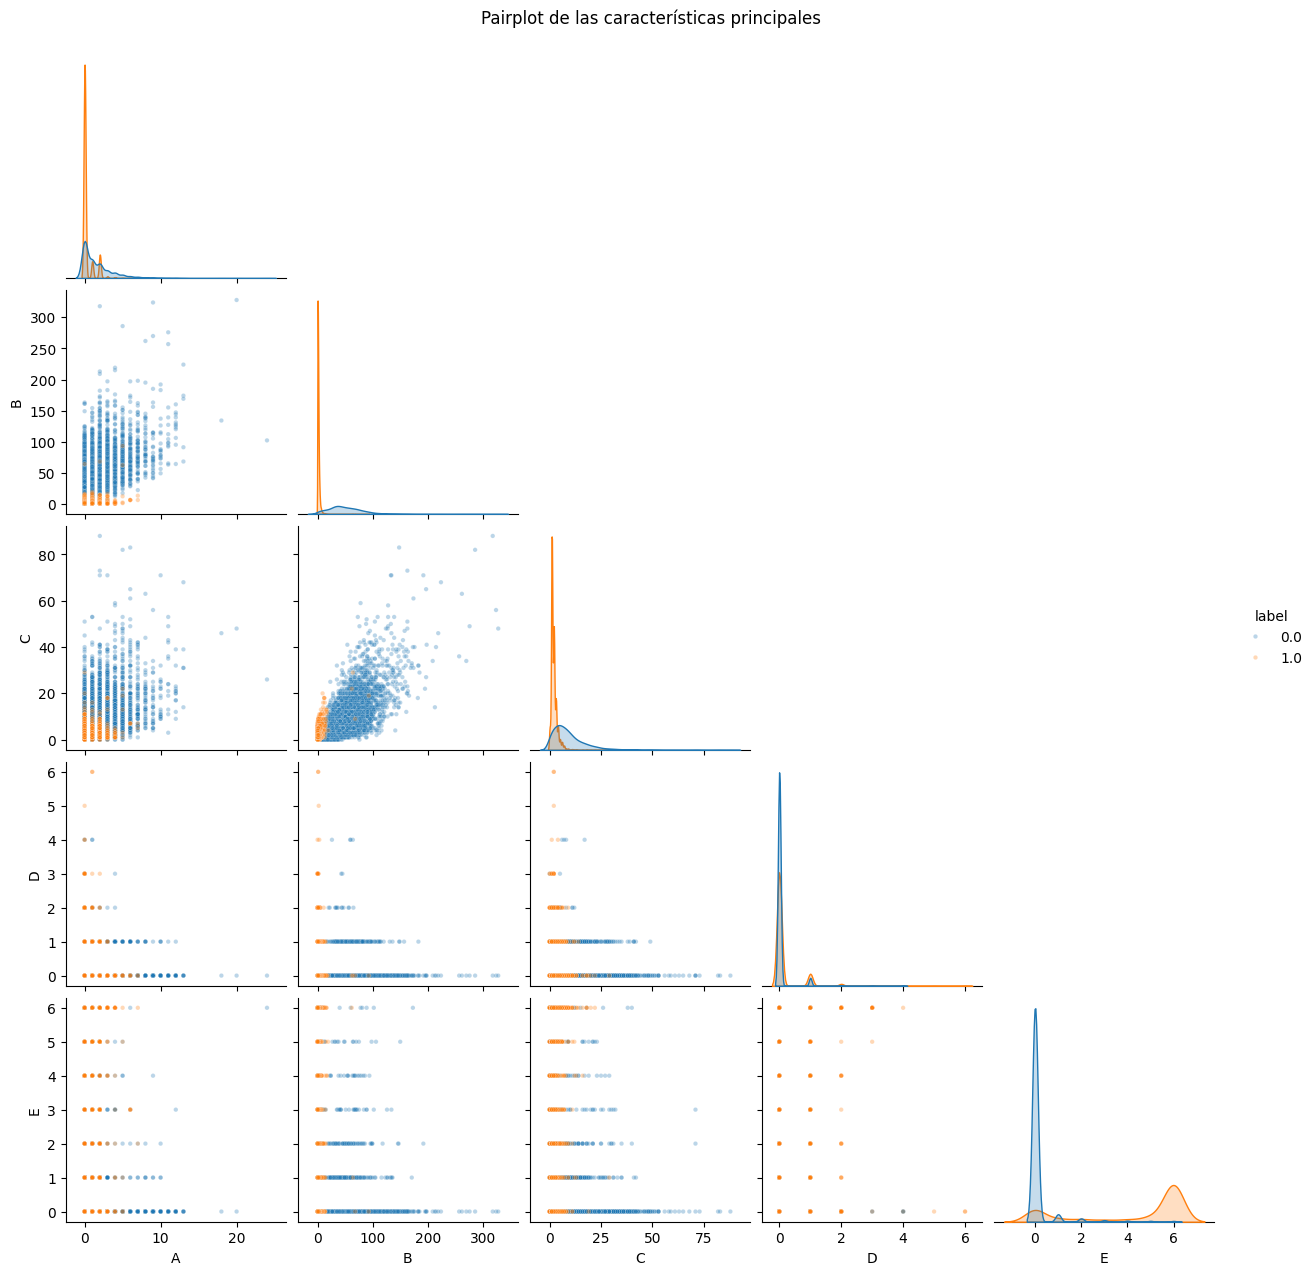

In [11]:
# Crear una matriz de gráficos de dispersión (pairplot)
import seaborn as sns
import matplotlib.pyplot as plt


columnas_plot = ['A', 'B', 'C', 'D', 'E', 'label']

sns.pairplot(
    data[columnas_plot],
    hue='label',
    corner=True, # Me quedo solo con el triangulo inferio ya que el resto es redundante
    plot_kws={'alpha': 0.3, 's': 10}
)

plt.suptitle('Pairplot de las características principales', y=1.02)
plt.show()


En la representación gráfica podemos ver como las clases dadas por la variable `label` no están completamente separadas en el espacio original de variables. Esto se ve en el solapamiento entre ambas categorías en la mayoría de combinaciones de características.

En concreto, si nos fijamos en las gráficas de la diagonal, podemos ver que la variable `E` es la que parece tener más capacidad de separar entre clases, ya que la clase `0.0` aparece principalmente en valores bajos y la clase `1.0` aparece principalmente en valores altos. Por tanto, esta variable podría ser especialmente relevante para diferenciar entre etiquetas.

Como hemos visto anteriormente, todas las variables analizadas (`A`, `B`, `C`, `D` y `E`) son de tipo entero (`int64`), por lo que tienen naturaleza discreta. Sin embargo, este comportamiento discreto es más visible en las variables `D` y `E`, donde los puntos se agrupan en bandas verticales u horizontales. Si nos fijamos en las estadísticas descriptivas que hemos obtenido anteriormente, vemos que `D` y `E` solo toman valores entre 0 y 6, mientras que los valores máximos de `A`,`B` y `C` son 24, 328 y 88 respectivamente y el valor mínimo para todas es 0. Por tanto, estas últimas presentan rangos más amplios y mayor número de valores distintos.

El que los rangos difieran tanto entre las variables también justifica el uso de la estandarización antes de aplicar PCA o t-SNE, ya que de esta forma evitamos que las variables con vaor rango dominen la proyección final.

Además, podemos ver como `B` y `C` parecen mostrar una relación positiva, lo que indica la existencia de cierta correlación entre características. Este tipo de relación puede ser relevante antes de aplicar PCA, ya que PCA puede resumir información compartida entre variables correlacionadas.

Vamos a ver unos ejemplos de los registros:

In [12]:
muestra_aleatoria = data.sample(
    n=20,
    random_state=24
)

display(muestra_aleatoria)

,A,B,C,D,E,comentario,label,A_t,B_t,C_t,...,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
5821,2,2,1,0,6,"terrorista,informativo,",1.0,1.851102,-0.289909,-0.164022,...,-0.536652,-0.303622,-0.771127,4.413232,0.047552,0.120770,-0.691176,0.068328,-0.391047,-0.993166
2516,2,15,1,0,0,"sap,mes,eín,miquel,serra,debajo,olivo,trozo,ve...",0.0,1.851102,0.349514,-0.164022,...,0.646986,-0.303622,-0.771127,-0.983118,-0.057328,-0.145599,-0.185626,0.068328,0.087112,0.221244
4282,4,40,6,0,0,"poner,escribir,despues,conocer,noticia,muertir...",0.0,3.990202,1.579174,1.096297,...,6.301221,4.374447,-1.662227,-2.119191,1.731243,-0.657848,-0.838697,-0.456692,-0.582242,0.221244
4173,0,38,3,0,0,"evaristir,perez,castro,antepasado,familia,pere...",0.0,-0.287998,1.480801,0.340105,...,-0.426468,-0.097950,0.119973,0.152955,0.503628,-0.616868,-0.786452,-0.141680,-0.180630,0.221244
255,3,93,9,0,0,"caber,duda,usuario,videojuego,representado,mej...",0.0,2.920652,4.186052,1.852489,...,12.226001,5.410475,-1.216677,-1.551155,7.754615,-1.743814,-2.223207,-0.771705,-0.983855,0.221244
4473,1,38,6,0,0,"tras,publicacion,adversario,emmanuel,carrèrar,...",0.0,0.781552,1.480801,1.096297,...,1.157323,0.856813,-0.325577,-0.415081,1.623398,-0.616868,-0.786452,-0.456692,-0.582242,0.221244
9430,0,3,5,0,6,"prision,derecho,servicio,medico,caso,covid,dem...",1.0,-0.287998,-0.240723,0.844233,...,0.069328,-0.243137,0.119973,-0.686619,-0.203226,0.100280,-0.573910,-0.351688,2.012745,-0.993166
8613,0,0,2,0,6,"sinverguenza,arruinar,empezar,sector,servicio,...",1.0,-0.287998,-0.388282,0.088042,...,0.111824,-0.025356,0.119973,-0.686619,-0.034185,0.161750,-0.925708,-0.036676,0.209901,-0.993166
2189,2,49,22,0,0,"resto,gran,perro,cazador,prehistorico,hallado,...",0.0,1.851102,2.021851,5.129319,...,3.742652,9.494893,-0.771127,-0.983118,10.370720,-0.842257,-1.073803,-2.136758,-2.724175,0.221244
3506,11,98,21,0,0,"medio,centenar,experto,internacional,cambio,cl...",0.0,11.477051,4.431984,4.877255,...,50.866111,55.976511,-4.781078,-6.095448,21.615920,-1.846264,-2.353822,-2.031754,-2.590305,0.221244


El dataset parece estar orientado a una tarea de clasificación textual, posiblemente relacionada con la detección de mensajes negativos o de odio, ya que contiene una columna `comentario` con texto preprocesado y una variable objetivo `label`.

La columna `comentario` parece contener, dadas las explicaciones del notebook, no el texto original, sino una versión procesada del mensaje, donde se han eliminado elementos como URLs, emojis, signos de puntuación, stopwords y palabras poco informativas, y posteriormente se ha aplicado tokenización y lematización.

Las variables `A`, `B`, `C`, `D` y `E` representan características extraídas. `A` recoge el conteo de palabras positivas, `B` el conteo de palabras negativas, `C` el número de bigramas comunes, `D` el número de menciones a otros usuarios y `E` la categoría de sentimiento obtenida mediante la librería `pysentimiento` en español. Sin embargo, no sabemos con certeza si estas características se han extraido del texto original o del comentario final tokenizado.

Para comprobar si las variables `A` y `B` se han calculado directamente a partir del campo `comentario`, vamos acontar el número de tokens presentes en dicho campo. Dado que los comentarios aparecen como una secuencia de palabras separadas por comas, se ha considerado cada elemento separado por coma como una palabra o token, eliminando posibles elementos vacíos derivados de la coma final.

La hipótesis que vamos a evaluar es que, si `A` representa el conteo de palabras positivas y `B` el conteo de palabras negativas presentes en el comentario, entonces la suma `A + B` debería ser menor o igual que el número total de palabras del comentario. Esto se debe a que no todas las palabras tienen por qué aportar polaridad positiva o negativa, pero el número de palabras positivas y negativas no debería superar el número total de palabras disponibles.

Si aparecen registros donde `A + B` es mayor que el número de palabras del campo `comentario`, esto sugeriría que `A` y `B` no se han calculado únicamente sobre la versión procesada almacenada en `comentario` o que hay un error en esos registros.

In [13]:
# Comprobar si A + B es menor o igual que el número de palabras del comentario

# Copiamos el dataset para no modificar el original
df_check = data.copy()

# Contar el número de palabras/tokens presentes en la columna comentario
# Los comentarios parecen estar separados por comas y pueden terminar con una coma final
df_check['num_palabras_comentario'] = (
    df_check['comentario']
    .fillna('')
    .astype(str)
    .str.split(',')
    .apply(lambda palabras: len([p for p in palabras if p.strip() != '']))
)

# Calcular la suma de palabras positivas y negativas
df_check['A_mas_B'] = df_check['A'] + df_check['B']

# Comprobar si se cumple la hipótesis
df_check['cumple_hipotesis'] = df_check['A_mas_B'] <= df_check['num_palabras_comentario']

# Resumen de resultados
total_registros = len(df_check)
registros_cumplen = df_check['cumple_hipotesis'].sum()
registros_no_cumplen = total_registros - registros_cumplen

print(f"Total de registros analizados: {total_registros}")
print(f"Registros que cumplen A + B <= nº palabras comentario: {registros_cumplen}")
print(f"Registros que NO cumplen la hipótesis: {registros_no_cumplen}")
print(f"Porcentaje que cumple la hipótesis: {registros_cumplen / total_registros * 100:.2f}%")

# Mostrar algunos casos donde no se cumple
print("\nEjemplos de registros donde A + B es mayor que el número de palabras del comentario:")
display(
    df_check.loc[
        ~df_check['cumple_hipotesis'],
        ['comentario', 'A', 'B', 'A_mas_B', 'num_palabras_comentario', 'label']
    ].sample(n=20,random_state=24)
)

Total de registros analizados: 10000
Registros que cumplen A + B <= nº palabras comentario: 9871
Registros que NO cumplen la hipótesis: 129
Porcentaje que cumple la hipótesis: 98.71%

Ejemplos de registros donde A + B es mayor que el número de palabras del comentario:


,comentario,A,B,A_mas_B,num_palabras_comentario,label
5628,"terrorismo,informativo,",2,1,3,2,1.0
5830,"terrorista,informativo,",2,2,4,2,1.0
5621,"terrorismo,informativo,",2,1,3,2,1.0
5656,"terrorismo,informativo,",2,1,3,2,1.0
6473,"terrorista,informativo,",2,2,4,2,1.0
5662,"terrorismo,informativo,",2,1,3,2,1.0
5832,"terrorista,informativo,",2,2,4,2,1.0
5826,"terrorista,informativo,",2,2,4,2,1.0
5654,"terrorismo,informativo,",2,1,3,2,1.0
5666,"terrorismo,informativo,",2,1,3,2,1.0


Vemos que tenemos registros que no cumplen la hipótesis y que, aunque el notebook indica que se han eliminado duplicados, existen comentarios con los mismos valores. La eliminación de duplicados puede referirse a duplicados completos o a duplicados existentes en una fase anterior del procesamiento. En el dataset final todavía pueden aparecer comentarios repetidos en la columna `comentario` como vemos en el resultado anterior.

Esto no significa necesariamente que existan filas completamente duplicadas, ya que dos registros con el mismo texto procesado pueden diferir en otras variables o incluso proceder de mensajes originales distintos que, tras la limpieza, tokenización y lematización, han quedado representados mediante los mismos tokens.

Por tanto, conviene distinguir entre duplicados completos del dataset y duplicados parciales según la columna `comentario`. Ya que, para el análisis de reducción de dimensionalidad, si las filas tienen valores distintos en las variables numéricas, no son duplicados exactos desde el punto de vista del espacio de características.

In [14]:
# Comprobar duplicados completos en todo el dataset
duplicados_completos = data.duplicated().sum()

print(f"Número de filas completamente duplicadas: {duplicados_completos}")

Número de filas completamente duplicadas: 539


In [15]:
# Comprobar comentarios duplicados
duplicados_comentario = data.duplicated(subset=['comentario']).sum()

print(f"Número de comentarios duplicados según la columna 'comentario': {duplicados_comentario}")

Número de comentarios duplicados según la columna 'comentario': 539


Vemos que siguen existiendo 539 filas totalmente duplicadas. A esto se suma 129 registros que no cumplen con la hipótesis planteada y que además muchos de ellos parecen pertenecer al grupo de duplicados.

Vamos a eliminar estos registros pues aportan ruido a nuestro dataset.

Para ello vamos a crear un nuevo dataset llamado `dataset_limpio`.

Para obtenerlo voy a eliminar primero los registros incoherentes, es decir, los que no cumplen la hipótesis planteada, y voy a guardar el resultado en `data_sin_incoherentes`. Después voy a eliminar los suplicados de este dataset.

In [16]:
# Partimos del dataframe donde ya habías calculado la hipótesis
# df_check contiene: num_palabras_comentario, A_mas_B y cumple_hipotesis

print("Registros iniciales:", len(df_check))

# Filas que no cumplen la hipótesis
num_no_cumplen = (~df_check['cumple_hipotesis']).sum()
print("Filas que no cumplen la hipótesis:", num_no_cumplen)

# Eliminar filas que no cumplen la hipótesis
data_sin_incoherentes = df_check[df_check['cumple_hipotesis']].copy()

print("Registros tras eliminar incoherentes:", len(data_sin_incoherentes))
print("Filas eliminadas:", len(df_check) - len(data_sin_incoherentes))

Registros iniciales: 10000
Filas que no cumplen la hipótesis: 129
Registros tras eliminar incoherentes: 9871
Filas eliminadas: 129


In [17]:
# Comprobar duplicados completos restantes
duplicados_restantes = data_sin_incoherentes.duplicated().sum()

print("Duplicados completos restantes:", duplicados_restantes)

# Eliminar duplicados completos
data_limpio = data_sin_incoherentes.drop_duplicates().copy()

print("Registros tras eliminar incoherentes y duplicados:", len(data_limpio))
print("Filas duplicadas eliminadas:", len(data_sin_incoherentes) - len(data_limpio))

Duplicados completos restantes: 414
Registros tras eliminar incoherentes y duplicados: 9457
Filas duplicadas eliminadas: 414


A continuación voy a comprobar como está el balanceo de las clases en el dataset limpio:

In [18]:
# Comparar balanceo antes y después de la limpieza

balance_original = data['label'].value_counts().sort_index()
balance_original_pct = data['label'].value_counts(normalize=True).sort_index() * 100

balance_limpio = data_limpio['label'].value_counts().sort_index()
balance_limpio_pct = data_limpio['label'].value_counts(normalize=True).sort_index() * 100

comparacion_balanceo = pd.DataFrame({
    'Original': balance_original,
    'Original (%)': balance_original_pct.round(2),
    'Limpio': balance_limpio,
    'Limpio (%)': balance_limpio_pct.round(2)
})

display(comparacion_balanceo)

,Original,Original (%),Limpio,Limpio (%)
label,,,,
0.0,5000,50.0,4970,52.55
1.0,5000,50.0,4487,47.45


Vemos que ahora los dataset están ligeramente desbalanceados. Por lo tanto voy a eliminar registros aleatoriamente de la clase mayoritaria para igualarla con la clase minoritaria. Para que sea reproducible voy a usar una semilla.

In [19]:
# Balanceo del dataset mediante submuestreo aleatorio de la clase mayoritaria

semilla = 42

print("Distribución de clases antes del balanceo:")
display(data_limpio['label'].value_counts().sort_index())

conteo_clases = data_limpio['label'].value_counts()
n_minoritario = conteo_clases.min()

datasets_balanceados = []

for etiqueta in conteo_clases.index:
    subset_clase = data_limpio[data_limpio['label'] == etiqueta]

    subset_balanceado = subset_clase.sample(
        n=n_minoritario,
        random_state=semilla
    )

    datasets_balanceados.append(subset_balanceado)

data_balanceado = (
    pd.concat(datasets_balanceados, axis=0)
    .sample(frac=1, random_state=semilla)
    .reset_index(drop=True)
)

print("\nDistribución de clases después del balanceo:")
display(data_balanceado['label'].value_counts().sort_index())

print(f"\nNúmero total de registros tras el balanceo: {len(data_balanceado)}")

Distribución de clases antes del balanceo:


,count
label,
0.0,4970
1.0,4487



Distribución de clases después del balanceo:


,count
label,
0.0,4487
1.0,4487



Número total de registros tras el balanceo: 8974


Mostramos un ejemplo del nuevo dataset:

In [20]:
muestra_aleatoria = data_balanceado.sample(
    n=20,
    random_state=24
)

display(muestra_aleatoria)

,A,B,C,D,E,comentario,label,A_t,B_t,C_t,...,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10,num_palabras_comentario,A_mas_B,cumple_hipotesis
2179,0,1,1,0,5,"gilipolla,soltar,americo,profundo,",1.0,-0.287998,-0.339096,-0.164022,...,-0.546690,0.055619,0.141260,-0.643686,0.068328,-0.311354,-0.790765,4,1,True
3016,2,33,5,0,0,"fotografia,tomado,dán,mads,nissen,,primero,abr...",0.0,1.851102,1.234869,0.844233,...,-0.983118,1.042517,-0.514418,-0.655837,-0.351688,-0.448371,0.221244,246,35,True
6716,0,0,3,1,6,"@carlo,latre,acabar,,arrastrandotar,mierdo,pre...",1.0,-0.287998,-0.388282,0.340105,...,-0.686619,-0.132057,-0.582519,-0.925708,0.510242,0.810849,3.576752,7,0,True
468,0,0,3,1,6,"ahi,marques,chepa,florida,habrar,hablar,subida...",1.0,-0.287998,-0.388282,0.340105,...,-0.686619,-0.132057,-0.582519,-0.925708,0.510242,0.810849,3.576752,15,0,True
8036,1,72,3,0,0,"grupo,investigador,estadounidense,revelar,ciud...",0.0,0.781552,3.153138,0.340105,...,-0.415081,1.072399,-1.313526,-1.674628,-0.141680,-0.180630,0.221244,401,73,True
7684,1,13,3,0,0,"guardia,civil,detenido,puesto,disposicion,judi...",0.0,0.781552,0.251141,0.340105,...,-0.415081,0.085414,-0.104620,-0.133381,-0.141680,-0.180630,0.221244,73,14,True
1271,1,1,0,1,3,"arcada,oir,hablar,penar,politico,cuantar,false...",1.0,0.781552,-0.339096,-0.416086,...,0.724112,0.141093,-0.508727,-0.314174,-0.624232,-0.385506,1.389986,20,2,True
8838,1,32,5,0,1,"precio,luz,seguir,subir,forma,imparable,poner,...",0.0,0.781552,1.185682,0.844233,...,-0.035350,1.000992,-0.493928,-0.053629,-0.351688,-0.038185,0.018842,222,33,True
6048,3,55,9,1,0,"apenas,pasado,semana,inicio,crisis,sismico,fin...",0.0,2.920652,2.316969,1.852489,...,-1.551155,4.292160,3.476023,-1.230540,2.779188,-0.983855,-0.796779,550,58,True
5324,1,84,16,0,3,"tras,mes,bloqueo,ayuntamiento,granada,alcalde,...",0.0,0.781552,3.743375,3.616936,...,0.724112,13.539547,-1.559405,3.468259,-1.506733,3.351113,-0.385961,557,85,True


In [21]:
# Exportar el dataset balanceado a CSV
data_balanceado.to_csv("out_balanceado.csv", index=False)

El notebook nos dice al principio que la variable `E` es una categoría de sentimiento, por lo que no es una variable numérica sino categórica.

Vamos a comenzar viendo la proporción de cada valor de `E` en el datset:

In [22]:
# Análisis univariante de la variable categórica no ordinal E

conteo_E = data_balanceado['E'].value_counts().sort_index()
porcentaje_E = data_balanceado['E'].value_counts(normalize=True).sort_index() * 100

resumen_E = pd.DataFrame({
    'Frecuencia': conteo_E,
    'Porcentaje (%)': porcentaje_E.round(2)
})

display(resumen_E)

,Frecuencia,Porcentaje (%)
E,,
0,5098,56.81
1,344,3.83
2,241,2.69
3,166,1.85
4,190,2.12
5,272,3.03
6,2663,29.67


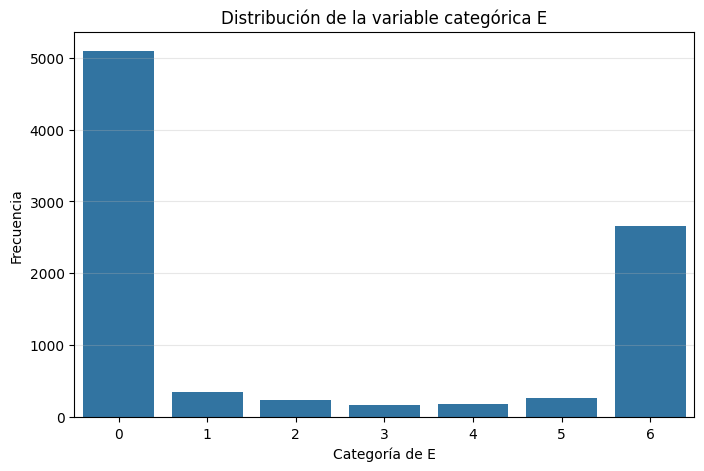

In [23]:
# Gráfico de frecuencias de E

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data_balanceado,
    x='E',
    order=sorted(data_balanceado['E'].unique())
)

plt.title('Distribución de la variable categórica E')
plt.xlabel('Categoría de E')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Vamos a ver como varía la proporción de la variable `E` según la etiqueta:

In [24]:
# Tabla de contingencia entre E y label

tabla_E_label = pd.crosstab(
    data_balanceado['E'],
    data_balanceado['label'],
    margins=True
)

display(tabla_E_label)

label,0.0,1.0,All
E,,,
0,4189,909,5098
1,144,200,344
2,68,173,241
3,32,134,166
4,23,167,190
5,16,256,272
6,15,2648,2663
All,4487,4487,8974


In [25]:
# Distribución porcentual de label dentro de cada categoría de E

tabla_E_label_pct = pd.crosstab(
    data_balanceado['E'],
    data_balanceado['label'],
    normalize='index'
) * 100

display(tabla_E_label_pct.round(2))

label,0.0,1.0
E,,
0,82.17,17.83
1,41.86,58.14
2,28.22,71.78
3,19.28,80.72
4,12.11,87.89
5,5.88,94.12
6,0.56,99.44


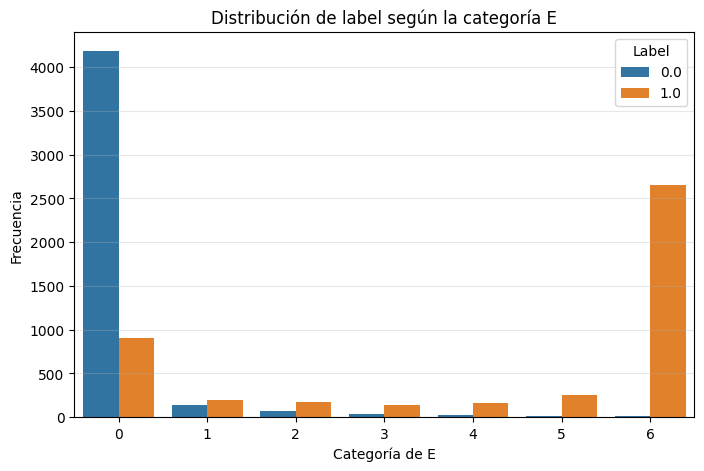

In [26]:
# Visualización de la relación entre E y label

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data_balanceado,
    x='E',
    hue='label',
    order=sorted(data_balanceado['E'].unique())
)

plt.title('Distribución de label según la categoría E')
plt.xlabel('Categoría de E')
plt.ylabel('Frecuencia')
plt.legend(title='Label')
plt.grid(axis='y', alpha=0.3)
plt.show()

El análisis de la variable `E` muestra una asociación clara con la variable `label`. Bajo la hipótesis de que la clase positiva (`label = 1`) representa mensajes de odio o mensajes problemáticos, se observa que una parte importante de estos registros se concentra en la categoría `E = 6`. En cambio, los registros de la clase negativa (`label = 0`) aparecen asociados principalmente con la categoría `E = 0`.

Esto sugiere que `E` contiene información muy discriminante respecto a la etiqueta y que, por sí sola, podría contribuir a una separación clara entre clases. Sin embargo, `E` debe interpretarse como una variable categórica no ordinal, es decir, que aunque esté codificada con números, no se puede asumir que exista una distancia cuantitativa entre sus categorías ni que pasar de `E = 0` a `E = 6` represente un aumento lineal de alguna magnitud.

Por este motivo, se decide no incluir `E` en PCA ni en t-SNE como variable numérica estandarizada. Incluirla directamente podría distorsionar la proyección, ya que el algoritmo interpretaría sus códigos como valores continuos.

Vamos a definir las distintas variables para hacer un estudio de cada tipo:

In [27]:
# Definición de variables para el análisis exploratorio

variables_numericas = ['A', 'B', 'C', 'D']
variable_categorica = 'E'
variable_objetivo = 'label'

print("Variables numéricas:", variables_numericas)
print("Variable categórica no ordinal:", variable_categorica)
print("Variable objetivo:", variable_objetivo)

print("\nDimensiones del dataset balanceado:")
print(data_balanceado.shape)

print("\nPrimeras filas:")
display(data_balanceado.head())

Variables numéricas: ['A', 'B', 'C', 'D']
Variable categórica no ordinal: E
Variable objetivo: label

Dimensiones del dataset balanceado:
(8974, 25)

Primeras filas:


,A,B,C,D,E,comentario,label,A_t,B_t,C_t,...,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10,num_palabras_comentario,A_mas_B,cumple_hipotesis
0,1,59,6,0,0,"tribunal,constitucional,declarado,ilegal,confi...",0.0,0.781552,2.513715,1.096297,...,-0.415081,2.755778,-1.047156,-1.335031,-0.456692,-0.582242,0.221244,287,60,True
1,0,67,3,0,0,"canado,esfuerzo,reconciliacion,pueblo,indigena...",0.0,-0.287998,2.907206,0.340105,...,0.152955,0.988757,-1.211076,-1.544014,-0.141680,-0.180630,0.221244,586,67,True
2,0,0,2,0,5,"gobierno,hacer,pasar,pelota,comunidad,inutil,",1.0,-0.287998,-0.388282,0.088042,...,-0.546690,-0.034185,0.161750,-0.737054,-0.036676,0.167124,-0.790765,6,0,True
3,1,30,7,0,0,"hacer,gala,apostar,confrontacion,jxcat,querer,...",0.0,0.781552,1.087310,1.348361,...,-0.415081,1.466086,-0.452948,-0.577469,-0.561697,-0.716113,0.221244,229,31,True
4,2,45,8,0,0,"grande,propiedad,salud,depender,estilo,vido,ca...",0.0,1.851102,1.825106,1.600425,...,-0.983118,2.920944,-0.760297,-0.969311,-0.666701,-0.849984,0.221244,297,47,True


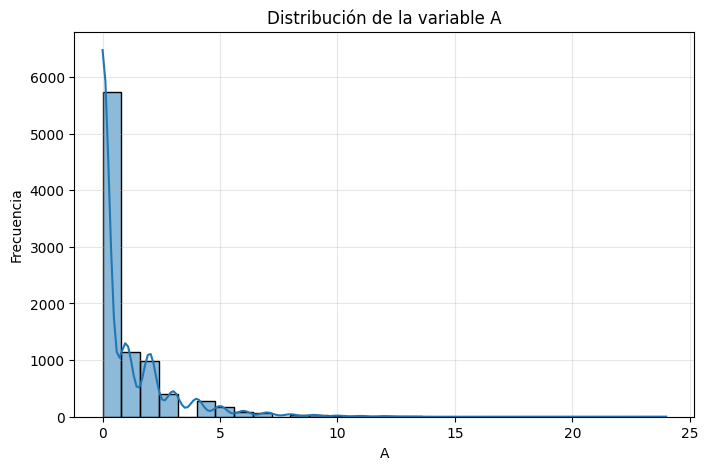

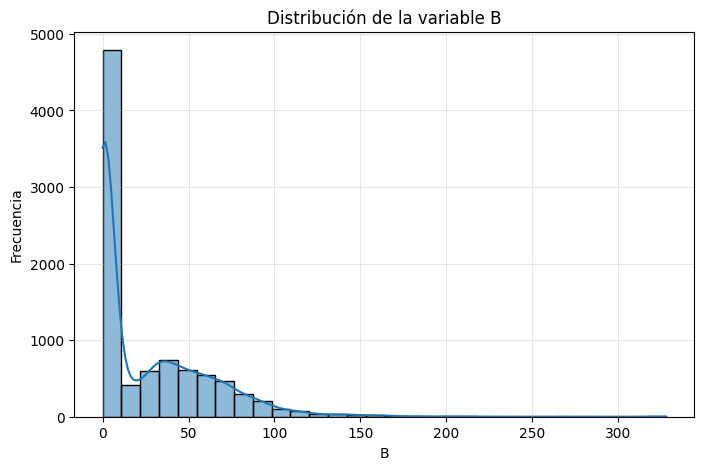

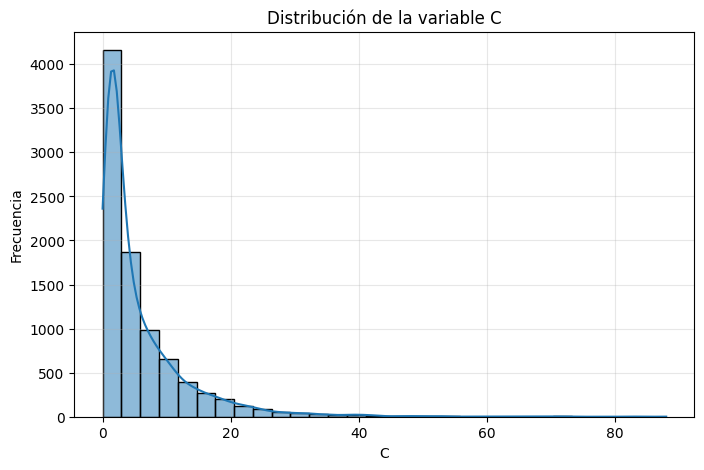

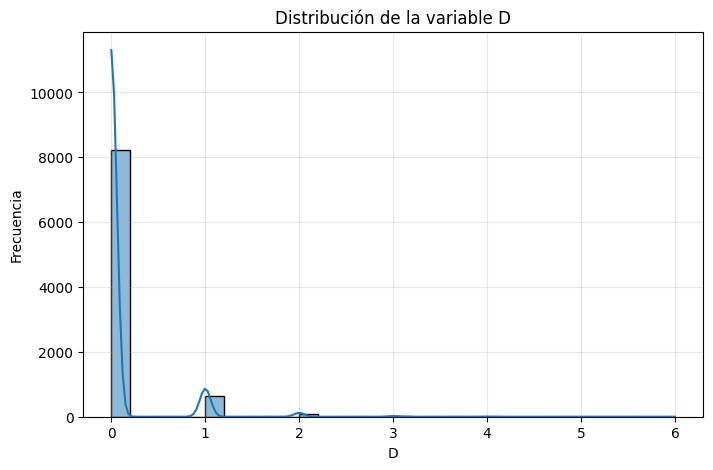

In [28]:
# Histogramas de las variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

for col in variables_numericas:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data_balanceado,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f'Distribución de la variable {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(alpha=0.3)
    plt.show()

Vemos que para todas las variables tenemos distribuciones de cola larga con mayor concentración de registros en los valores más bajos.

Vamos a representar boxplots para ver la presencia de outliers.

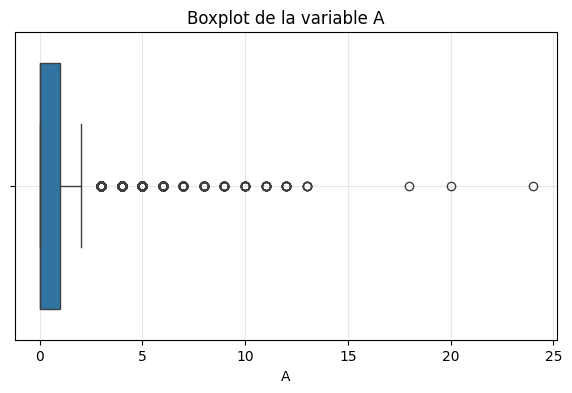

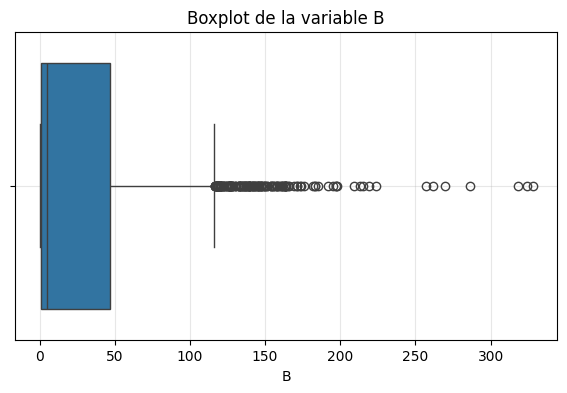

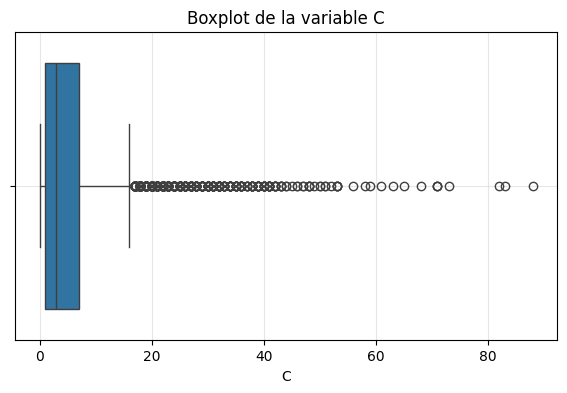

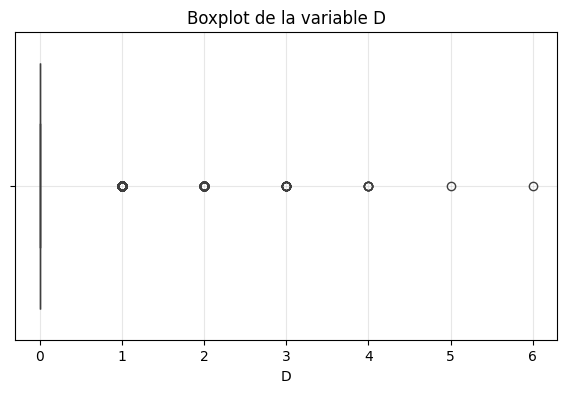

In [29]:
# Boxplots de las variables numéricas

for col in variables_numericas:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=data_balanceado,
        x=col
    )

    plt.title(f'Boxplot de la variable {col}')
    plt.xlabel(col)
    plt.grid(alpha=0.3)
    plt.show()

Vemos una alta presencia de outliers en la variables numéricas, en relación con las distribuciones de cola larga que hemos podido observar. En la práctica nos piden aplicar `Standarscaler`pero una alternativa robusta sería hacerlo tras aplicar una transformación logarítmica.

A continuación vamos a representar con boxplots las variables numéricas separando por categoría:

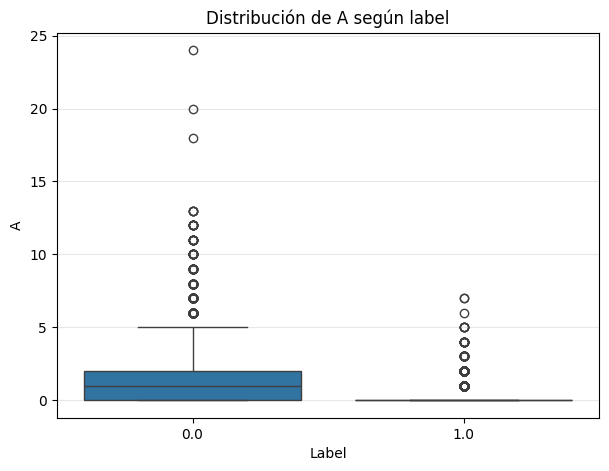

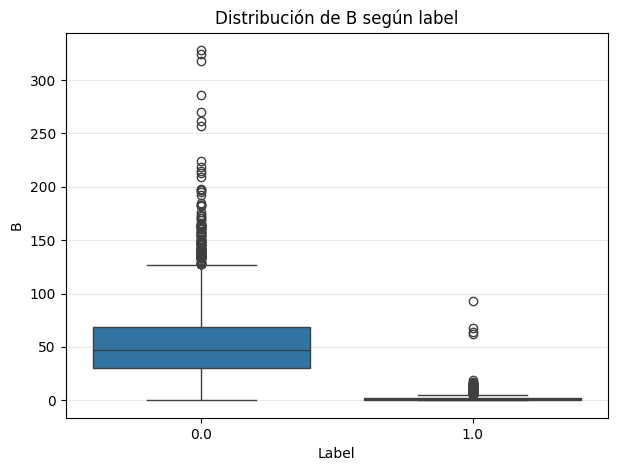

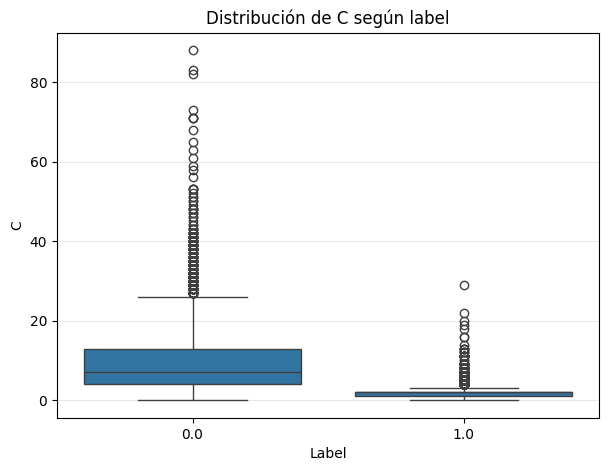

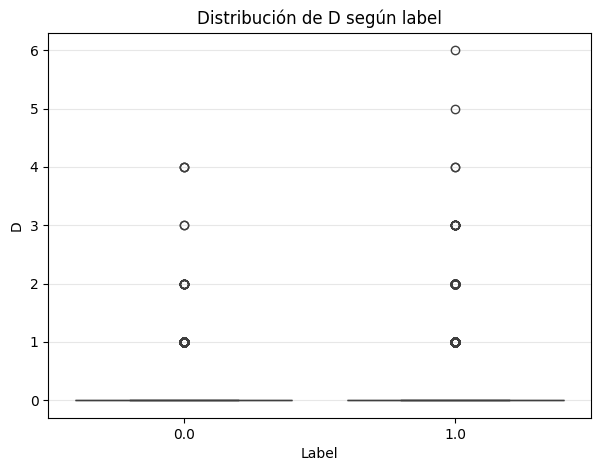

In [30]:
# Boxplots de variables numéricas según label

for col in variables_numericas:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=data_balanceado,
        x='label',
        y=col
    )

    plt.title(f'Distribución de {col} según label')
    plt.xlabel('Label')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Vemos que para la mayoría de variables numéricas los valores para la clase positiva se agrupan en rangos más bajos.

Ahora vamos a ver la matriz de correlación entre las variables numéricas y label:

In [31]:
# Matriz de correlaciones entre variables numéricas y label
# Se excluye E porque es categórica no ordinal

columnas_corr = variables_numericas + ['label']

matriz_corr = data_balanceado[columnas_corr].corr()

display(matriz_corr.round(3))

,A,B,C,D,label
A,1.000,0.585,0.525,-0.041,-0.397
B,0.585,1.000,0.787,-0.091,-0.733
C,0.525,0.787,1.000,-0.046,-0.507
D,-0.041,-0.091,-0.046,1.000,0.144
label,-0.397,-0.733,-0.507,0.144,1.000


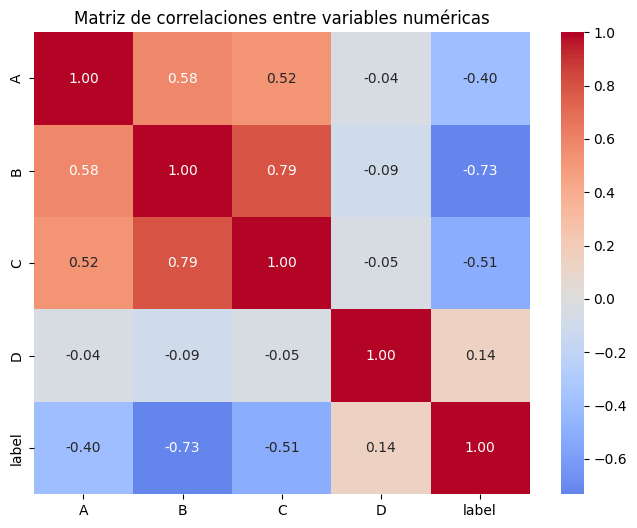

In [32]:
# Visualización de la matriz de correlaciones

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()

La matriz de correlación muestra una correlación positiva elevada entre `B` y `C` (`0.787`), y moderada entre `A` y `B` (`0.585`) y entre `A` y `C` (`0.525`). Esto indica que estas variables comparten información y puede existir cierta redundancia, lo que justifica el uso de PCA para resumir la variabilidad en menos componentes.

Respecto a `label`, la variable más relacionada es `B`, con una correlación negativa alta (`-0.733`).

La variable `D` apenas presenta correlación con el resto de variables y solo muestra una relación débil positiva con `label` (`0.144`), por lo que parece aportar menos información lineal para distinguir las clases.

In [33]:
# Eliminar columnas que empiecen por 'Valor_' y la columna 'comentario'

columnas_eliminar = [
    col for col in data_balanceado.columns
    if col.startswith('Valor_')
]

columnas_eliminar.append('comentario')

# Elimino las introducidas artificialmente para verificar la hipótesis y la variable E
columnas_eliminar.extend(['num_palabras_comentario',
                          'A_mas_B',
                          'cumple_hipotesis', 'E', 'E_t'])

df_reducido = data_balanceado.drop(columns=columnas_eliminar)

# Mostrar las primeras filas del nuevo dataframe para verificar
display(df_reducido.head())

# Compruebo las dimensiones
df_reducido.info()


,A,B,C,D,label,A_t,B_t,C_t,D_t
0,1,59,6,0,0.0,0.781552,2.513715,1.096297,-0.416577
1,0,67,3,0,0.0,-0.287998,2.907206,0.340105,-0.416577
2,0,0,2,0,1.0,-0.287998,-0.388282,0.088042,-0.416577
3,1,30,7,0,0.0,0.781552,1.087310,1.348361,-0.416577
4,2,45,8,0,0.0,1.851102,1.825106,1.600425,-0.416577


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8974 entries, 0 to 8973
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       8974 non-null   int64  
 1   B       8974 non-null   int64  
 2   C       8974 non-null   int64  
 3   D       8974 non-null   int64  
 4   label   8974 non-null   float64
 5   A_t     8974 non-null   float64
 6   B_t     8974 non-null   float64
 7   C_t     8974 non-null   float64
 8   D_t     8974 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 631.1 KB


A continuación, nos piden estandarizar las columnas excepto `label`, es decir estandarizar `A`, `B`, `C` y `D`. Sin embargo, la estandarización de estas variables ya las tenemos en `A_t`, `B_t`, `C_t` y `D_t`, según la información dada por el dataset. Así que lo que vamos a hacer es estadarizar las columnas como se nos pide y luego comprobar si los valores obtenidos coinciden con los valores existentes.


In [34]:
# Estandarizar las columnas, excepto 'label'

from sklearn.preprocessing import StandardScaler

# Columnas originales que se van a estandarizar
columnas_originales = ['A', 'B', 'C', 'D']

# Columnas transformadas que ya vienen en el dataset
columnas_transformadas = ['A_t', 'B_t', 'C_t', 'D_t']

# Estandarizar A, B, C, D y E
scaler = StandardScaler()

datos_estandarizados = scaler.fit_transform(
    df_reducido[columnas_originales]
)

# Crear un dataframe con las columnas estandarizadas calculadas
df_estandarizado_calculado = pd.DataFrame(
    datos_estandarizados,
    columns=[col + '_calc' for col in columnas_originales],
    index=df_reducido.index
)

# Añadir label sin estandarizar
df_estandarizado_calculado['label'] = df_reducido['label']

# Mostrar las primeras filas del dataframe estandarizado calculado
display(df_estandarizado_calculado.head())

# Comparar las columnas estandarizadas calculadas con las columnas transformadas existentes
df_comparacion = pd.concat(
    [
        df_reducido[columnas_transformadas],
        df_estandarizado_calculado[[col + '_calc' for col in columnas_originales]],
        df_reducido[['label']]
    ],
    axis=1
)

display(df_comparacion.head())



,A_calc,B_calc,C_calc,D_calc,label
0,0.038647,0.956923,0.032451,-0.271704,0.0
1,-0.534606,1.191225,-0.373708,-0.271704,0.0
2,-0.534606,-0.771059,-0.509095,-0.271704,1.0
3,0.038647,0.107576,0.167838,-0.271704,0.0
4,0.611900,0.546893,0.303224,-0.271704,0.0


,A_t,B_t,C_t,D_t,A_calc,B_calc,C_calc,D_calc,label
0,0.781552,2.513715,1.096297,-0.416577,0.038647,0.956923,0.032451,-0.271704,0.0
1,-0.287998,2.907206,0.340105,-0.416577,-0.534606,1.191225,-0.373708,-0.271704,0.0
2,-0.287998,-0.388282,0.088042,-0.416577,-0.534606,-0.771059,-0.509095,-0.271704,1.0
3,0.781552,1.087310,1.348361,-0.416577,0.038647,0.107576,0.167838,-0.271704,0.0
4,1.851102,1.825106,1.600425,-0.416577,0.611900,0.546893,0.303224,-0.271704,0.0


Podemos ver que los valores estandarizados calculados a partir del dataset limpio y balanceado no coinciden exactamente con las columnas `A_t`, `B_t`, `C_t` y `D_t` incluidas originalmente en el dataset.

Esto puede deberse a que dichas columnas transformadas fueron calculadas sobre el dataset original, antes de aplicar la limpieza de registros incoherentes, la eliminación de duplicados y el balanceo de clases. Al modificar el conjunto de datos, cambian la media y la desviación típica de las variables `A`, `B`, `C` y `D`, por lo que la estandarización debe recalcularse sobre el dataset final que se va a utilizar en el análisis.

También es posible que  fueran transformadas logarítmicamente para compensar outliers. Además si hacemos la estandarización así y entrenamos los modelos con estos datos estremos causando fuga de información entre ambos conjuntos, ya que la estandarización se ha calculado usando la media y la desviación típica d etodo el conjunto.

In [36]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler

X = df_reducido[['A', 'B', 'C', 'D']]
y = df_reducido['label']

# Primero split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Transformación logarítmica: no aprende parámetros
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

# Estandarización: ajustar SOLO con train
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

Con esto ya hemos separado las variables explicativas y la variable objetivo para poder usarlas en los siguientes apartados.

In [37]:
# Separar las características y las etiquetas
X = df_estandarizado_calculado.drop(columns=['label'])
y = df_estandarizado_calculado['label']

# Mostrar dimensiones para verificar
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Mostrar primeras filas de las características
display(X.head())

# Mostrar primeras etiquetas
display(y.head())


Dimensiones de X: (8974, 4)
Dimensiones de y: (8974,)


,A_calc,B_calc,C_calc,D_calc
0,0.038647,0.956923,0.032451,-0.271704
1,-0.534606,1.191225,-0.373708,-0.271704
2,-0.534606,-0.771059,-0.509095,-0.271704
3,0.038647,0.107576,0.167838,-0.271704
4,0.611900,0.546893,0.303224,-0.271704


,label
0,0.0
1,0.0
2,1.0
3,0.0
4,0.0


Como hemos dicho, en vez de usar la separación anterior que podría ocasionar dataleak, vamos a usar los conjuntos de entrenamiento y test generados

### PCA

A continuación vamos a aplicar PCA o Análisis de Componentes Principales. PCA es una técnica de reducción de dimensionalidad que permite transformar un conjunto de variables originales en un nuevo conjunto de variables no correlacionadas llamadas componentes principales. Estas componentes se construyen como combinaciones lineales de las variables originales y se ordenan según la cantidad de varianza que explican.

Como en el enunciado no dicen que el objetivo es aplicar técnicas para reducir la dimensionalidad a 2D vamos a aplicar PCA sobre las variables previamente estandarizadas para reducir el dataset de cuatro características (`A_calc`, `B_calc` y `C_calc`, `D_calc`) a dos componentes principales (`PC1` y `PC2`). Esta reducción nos va a permitir representar los datos en un plano bidimensional y ver si las clases definidas por `label` muestran algún tipo de separación.

No vamos a usar la variable `label` para ajustar el modelo PCA, ya que PCA es una técnica no supervisada. Sin embargo, la vamos a añadir posteriormente al dataframe resultante para poder colorear los puntos en la visualización y facilitar la interpretación de los resultados.


In [39]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=2)

# Ajustar PCA solo con entrenamiento
X_train_pca = pca.fit_transform(X_train_scaled)

# Aplicar la misma transformación al conjunto de test
X_test_pca = pca.transform(X_test_scaled)

# Crear DataFrames
df_train_pca = pd.DataFrame(
    X_train_pca,
    columns=['PC1', 'PC2'],
    index=X_train.index
)

df_test_pca = pd.DataFrame(
    X_test_pca,
    columns=['PC1', 'PC2'],
    index=X_test.index
)

# Añadir etiquetas
df_train_pca['label'] = y_train.values
df_test_pca['label'] = y_test.values

display(df_train_pca.head())
display(df_test_pca.head())

print("Varianza explicada por PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Varianza explicada por PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Varianza explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

,PC1,PC2,label
1052,-1.638495,-0.447200,1.0
935,3.730220,0.190157,0.0
280,2.532023,-0.031315,0.0
6935,1.242058,-0.148759,0.0
3811,3.015631,0.077578,0.0


,PC1,PC2,label
5842,-0.528479,-0.300802,1.0
3819,0.507791,-0.272892,0.0
6219,1.272648,-0.208791,0.0
292,-1.113963,-0.400875,1.0
8339,2.310114,-0.028460,0.0


Varianza explicada por PC1: 0.5648
Varianza explicada por PC2: 0.247
Varianza explicada acumulada: 0.8118


Vemos que que `PC1` explica el 56,48 % de la varianza total del dataset, que `PC2` explica el 24,70 % y que ambas componentes explican el 81,18 % de la variabilidad total de los datos. Por lo tanto, la reducción de dimensionalidad de cinco variables originales a dos componentes principales conserva una parte importante de la información del conjunto de datos y la representación bidimensional obtenida mediante PCA nos puede ser útil para visualizar la estructura general de los datos.

Sin embargo, debemos tener en cuenta que el 18,82 % de la varianza no queda representada en estas dos primeras componentes, por lo que la visualización en 2D implica cierta pérdida de información.


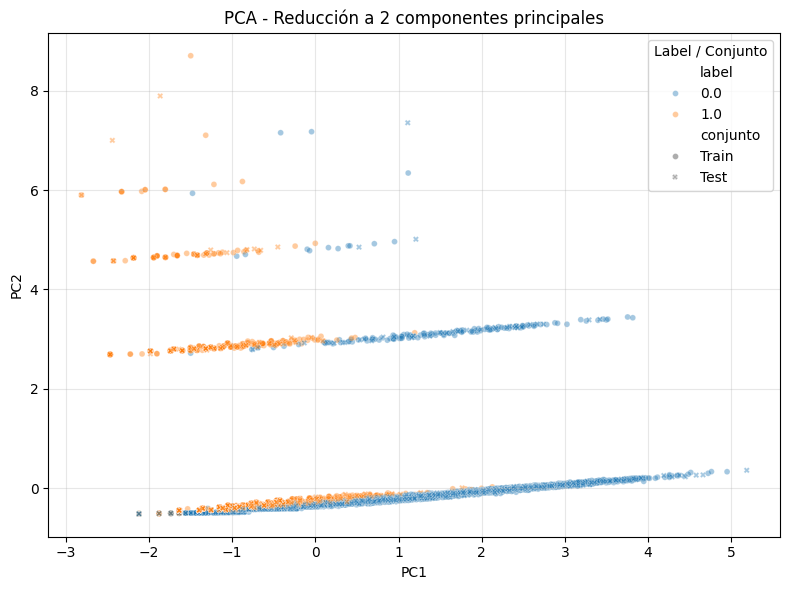

In [40]:
# Unir resultados PCA de entrenamiento y test para visualización

df_train_pca_plot = df_train_pca.copy()
df_train_pca_plot['conjunto'] = 'Train'

df_test_pca_plot = df_test_pca.copy()
df_test_pca_plot['conjunto'] = 'Test'

df_pca_plot = pd.concat(
    [df_train_pca_plot, df_test_pca_plot],
    axis=0
)

# Visualizar los resultados de PCA

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pca_plot,
    x='PC1',
    y='PC2',
    hue='label',
    style='conjunto',
    alpha=0.4,
    s=18
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Reducción a 2 componentes principales')
plt.legend(title='Label / Conjunto')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aunque vemos en la gráfica que las clases no quedan completamente separadas, ya que existe solapamiento entre `Label 0` y `Label 1`, sí que se ven ciertos patrones diferenciados.

La clase positiva (`Label 1`) se concentra principalmente en valores bajos o negativos de `PC1`, mientras que la clase negativa (`Label 0`) presenta una mayor dispersión y se extiende hacia valores más altos de `PC1`. Esto podría deberse a que la primera componente principal recogiera más información relevante para diferenciar parcialmente ambas clases.

Además, la distribución de los puntos muestra varias bandas o agrupaciones con cierta tendencia ascendente entre `PC1` y `PC2`. Esto puede estar relacionado con la naturaleza discreta de las variables originales, especialmente `D`, que toma un número limitado de valores y pueden generar franjas en la proyección.

Accuracy en entrenamiento con PCA: 0.962
Accuracy en test con PCA: 0.9476

Matriz de confusión en test:
[[846  52]
 [ 42 855]]

Reporte de clasificación en test:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95       898
         1.0       0.94      0.95      0.95       897

    accuracy                           0.95      1795
   macro avg       0.95      0.95      0.95      1795
weighted avg       0.95      0.95      0.95      1795



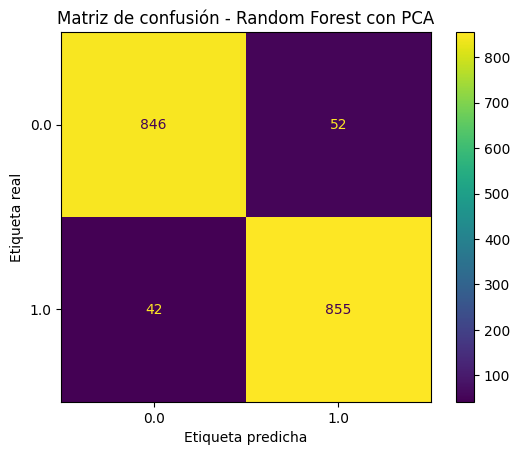

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Fijamos una semilla para que el resultado sea reproducible
semilla = 42
np.random.seed(semilla)

# Características PCA ya separadas en train y test
X_train_pca = df_train_pca[['PC1', 'PC2']]
X_test_pca = df_test_pca[['PC1', 'PC2']]

y_train_pca = df_train_pca['label']
y_test_pca = df_test_pca['label']

# Entrenar un modelo de clasificación Random Forest
clf_pca = RandomForestClassifier(
    n_estimators=100,      # número de árboles
    random_state=semilla,
    max_depth=5,           # profundidad máxima
    min_samples_leaf=5,    # mínimo de muestras en cada hoja
    n_jobs=1               # un solo hilo para mayor reproducibilidad
)

clf_pca.fit(X_train_pca, y_train_pca)

# Predecir y evaluar el modelo
y_train_pred_pca = clf_pca.predict(X_train_pca)
y_test_pred_pca = clf_pca.predict(X_test_pca)

print("Accuracy en entrenamiento con PCA:", round(accuracy_score(y_train_pca, y_train_pred_pca), 4))
print("Accuracy en test con PCA:", round(accuracy_score(y_test_pca, y_test_pred_pca), 4))

print("\nMatriz de confusión en test:")
cm_pca = confusion_matrix(y_test_pca, y_test_pred_pca)
print(cm_pca)

print("\nReporte de clasificación en test:")
print(classification_report(y_test_pca, y_test_pred_pca, zero_division=0))

# Representación gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pca,
    display_labels=clf_pca.classes_
)

disp.plot(values_format='d')
plt.title('Matriz de confusión - Random Forest con PCA')
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta real')
plt.show()

#### Analice los resultados obtenidos por PCA

De la representación 2D podemos decir que PCA permite identificar cierta estructura en los datos y una separación parcial entre clases, pero no consigue una discriminación completa. Por tanto, será interesante comparar estos resultados con t-SNE, que puede capturar relaciones no lineales y estructuras locales que PCA puede no estar representando adecuadamente.

Respecto a los resultados del modelo de clasificación, el Random Forest que hemos entrenado sobre las dos componentes principales obtiene un rendimiento alto. Hemos conseguido una accuracy de 0.962 en entrenamiento y 0.9476 en test. La diferencia entre ambas métricas es pequeña, por lo que no se observan indicios claros de sobreajuste. Por lo tanto, las dos componentes principales conservan información relevante para distinguir entre las dos clases y para que el modelo generalize sobre datos no vistos.

La matriz de confusión muestra que, en el conjunto de test, el modelo clasifica correctamente 846 registros de la clase 0 y 855 registros de la clase 1. Sin embargo, también comete 52 falsos positivos, es decir, registros reales de la clase 0 clasificados como clase 1, y 42 falsos negativos, registros reales de la clase 1 clasificados como clase 0.

En el reporte de clasificación se observa que, para la clase 0, el modelo obtiene una precisión de 0.95 y un recall de 0.94. Esto indica que, cuando el modelo predice la clase 0, suele acertar, aunque deja sin identificar algunos registros reales de esta clase. Para la clase 1, la precisión es de 0.94 y el recall asciende a 0.95. Esto significa que el modelo identifica correctamente la mayoría de los registros reales de la clase positiva, aunque todavía clasifica erróneamente algunos de ellos como clase 0.

Como ya hemos mencionado anteriormente, `PC1` explica el 56,48 % de la varianza total y `PC2` explica el 24,70 %, y acumulando entre ambas el 81,18 % de la variabilidad del dataset. Esto significa que la proyección bidimensional conserva una parte importante de la información original, lo que ayuda a explicar por qué el modelo obtiene buenos resultados usando PC1 y PC2. No obstante, como hemos dicho, también se pierde aproximadamente un 18,82 % de la varianza, por lo que parte de la información original no está representada en esta proyección. Esta pérdida puede contribuir a los errores observados en la matriz de confusión.

Por lo tanto, PCA permite visualizar los datos en dos dimensiones, conserva una proporción elevada de la variabilidad y mantiene suficiente información para que un modelo de clasificación obtenga un rendimiento alto. Aun así, la separación visual no es perfecta y existen errores de clasificación, especialmente falsos negativos en la clase positiva.

### t-SNE

El t-distributed Stochastic Neighbor Embedding o t-SNE  es una técnica no lineal de reducción de dimensionalidad especialmente utilizada para visualizar datos de alta dimensión en dos o tres dimensiones. Se centra en preservar las relaciones locales entre observaciones, a diferencia de PCA, que recordemos, busca maximizar la varianza global mediante combinaciones lineales de las variables originales. Por tanto, t-SNE intenta que los puntos que son similares en el espacio original aparezcan cercanos también en la representación reducida.

Vamos a aplicar t-SNE sobre las variables previamente estandarizadas, reduciendo el dataset a dos dimensiones (`tSNE1` y `tSNE2`) para poder representarlo gráficamente. La variable `label` no la utilizaremos para ajustar el algoritmo, ya que t-SNE es una técnica no supervisada, pero la añadiremos posteriormente al dataframe resultante para colorear los puntos y analizar visualmente si las clases presentan separación.

Para que el resultado sea reproducible, vamos a fijar una semilla mediante `random_state`. Además, vamos a fijar una perplejidad, que controla aproximadamente el número efectivo de vecinos considerados por el algoritmo, y una exageración temprana, que influye en la separación inicial entre agrupaciones durante las primeras iteraciones. También vamos a usar `init='pca'` para inicializar la proyección a partir de PCA, lo que nos va a aportar mayor estabilidad frente a una inicialización completamente aleatoria.


,tSNE1,tSNE2,label
0,-70.791100,24.761499,1.0
1,74.040543,74.971268,0.0
2,102.849411,-4.978155,0.0
3,39.021198,8.572601,0.0
4,70.951065,58.374641,0.0


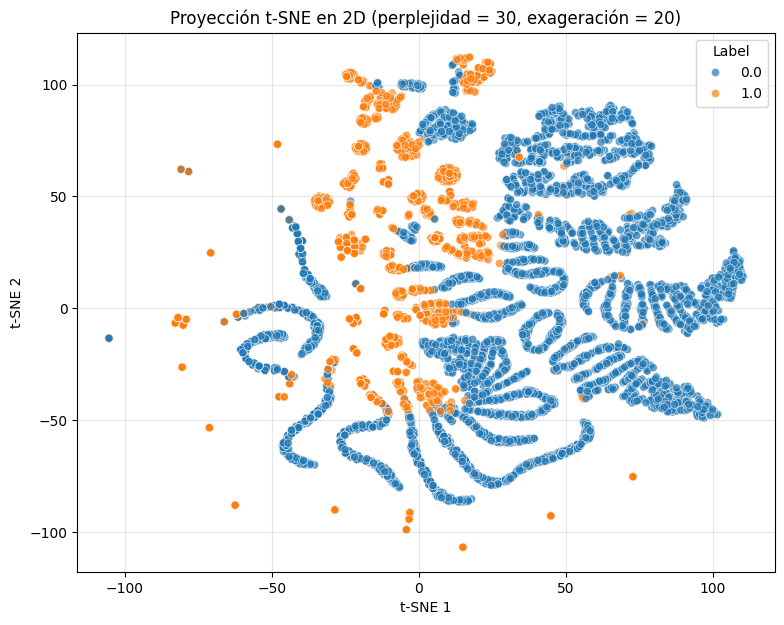

In [42]:
# Aplicar t-SNE
from sklearn.manifold import TSNE


# Fijamos una semilla para que el resultado sea reproducible
semilla = 42

# Número efectivo de vecinos
perplejidad = 30
# Controla la separación inicial entre agrupaciones
exageracion = 20

# Unimos train y test ya transformados y estandarizados
X_scaled_total = np.vstack([X_train_scaled, X_test_scaled])
y_total = pd.concat([y_train, y_test], axis=0)

# Creamos el modelo t-SNE con 2 componentes
tsne = TSNE(
    n_components=2,
    perplexity=perplejidad,
    early_exaggeration=exageracion,
    learning_rate='auto',
    init='pca',
    random_state=semilla
)

# Ajustamos t-SNE sobre las características transformadas y estandarizadas
X_tsne = tsne.fit_transform(X_scaled_total)

# Crear un DataFrame con los resultados de t-SNE
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['tSNE1', 'tSNE2']
)

# Añadimos la etiqueta para visualizar las clases
df_tsne['label'] = y_total.values

# Mostrar las primeras filas del dataframe resultante
display(df_tsne.head())

# Visualizar los resultados de t-SNE
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_tsne,
    x='tSNE1',
    y='tSNE2',
    hue='label',
    alpha=0.7,
    s=35
)

plt.title(f'Proyección t-SNE en 2D (perplejidad = {perplejidad}, exageración = {exageracion})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Label')
plt.grid(alpha=0.3)
plt.show()


,tSNE1,tSNE2,label
0,-72.821480,1.808245,1.0
1,57.395996,74.375168,0.0
2,90.780235,6.723624,0.0
3,46.721584,6.207627,0.0
4,58.841076,61.177235,0.0


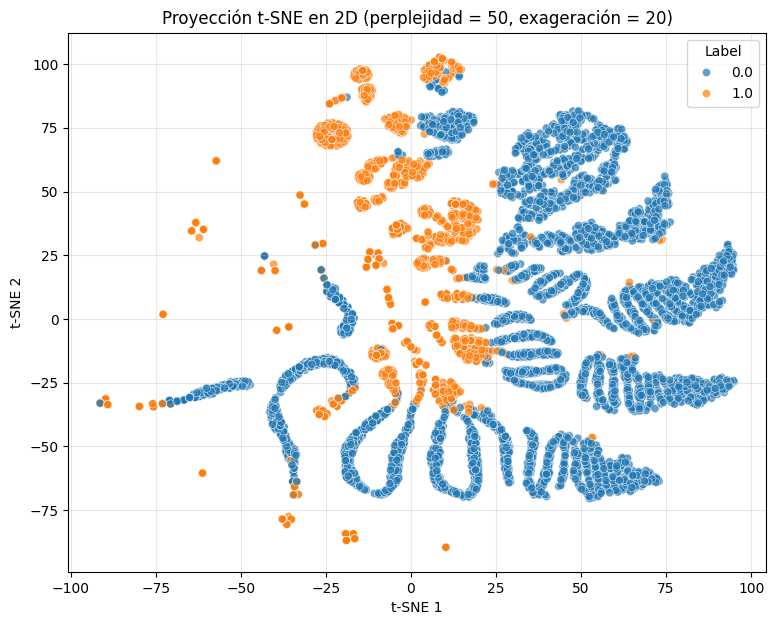

In [43]:
# Fijamos una semilla para que el resultado sea reproducible
semilla = 42

# Número efectivo de vecinos
perplejidad = 50
# Controla la separación inicial entre agrupaciones
exageracion = 20

# Unimos train y test ya transformados y estandarizados
X_scaled_total = np.vstack([X_train_scaled, X_test_scaled])
y_total = pd.concat([y_train, y_test], axis=0)

# Creamos el modelo t-SNE con 2 componentes
tsne = TSNE(
    n_components=2,
    perplexity=perplejidad,
    early_exaggeration=exageracion,
    learning_rate='auto',
    init='pca',
    random_state=semilla
)

# Ajustamos t-SNE sobre las características transformadas y estandarizadas
X_tsne = tsne.fit_transform(X_scaled_total)

# Crear un DataFrame con los resultados de t-SNE
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['tSNE1', 'tSNE2']
)

# Añadimos la etiqueta para visualizar las clases
df_tsne['label'] = y_total.values

# Mostrar las primeras filas del dataframe resultante
display(df_tsne.head())

# Visualizar los resultados de t-SNE
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_tsne,
    x='tSNE1',
    y='tSNE2',
    hue='label',
    alpha=0.7,
    s=35
)

plt.title(f'Proyección t-SNE en 2D (perplejidad = {perplejidad}, exageración = {exageracion})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Label')
plt.grid(alpha=0.3)
plt.show()

,tSNE1,tSNE2,label
0,-72.961761,3.931700,1.0
1,37.571487,69.966522,0.0
2,86.660461,36.745331,0.0
3,64.572525,3.796996,0.0
4,44.836575,60.238953,0.0


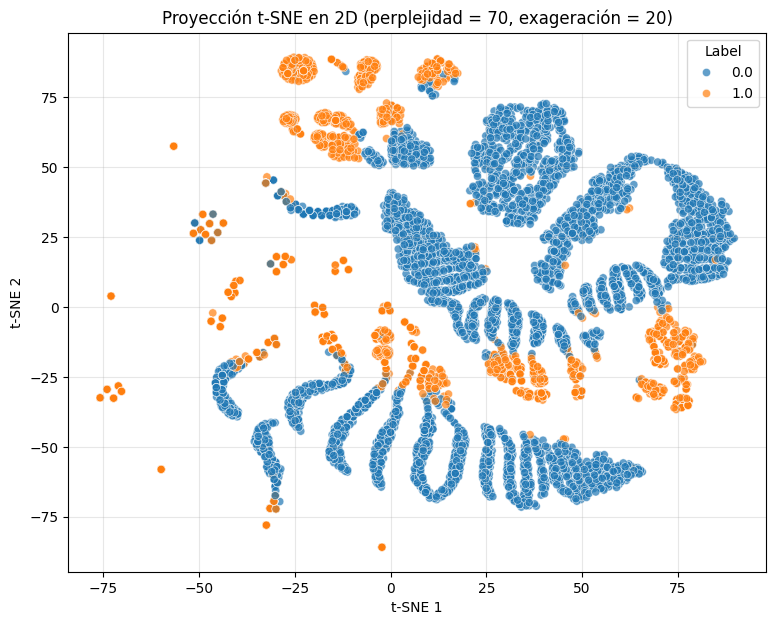

In [44]:
# Fijamos una semilla para que el resultado sea reproducible
semilla = 42

# Número efectivo de vecinos
perplejidad = 70
# Controla la separación inicial entre agrupaciones
exageracion = 20

# Unimos train y test ya transformados y estandarizados
X_scaled_total = np.vstack([X_train_scaled, X_test_scaled])
y_total = pd.concat([y_train, y_test], axis=0)

# Creamos el modelo t-SNE con 2 componentes
tsne = TSNE(
    n_components=2,
    perplexity=perplejidad,
    early_exaggeration=exageracion,
    learning_rate='auto',
    init='pca',
    random_state=semilla
)

# Ajustamos t-SNE sobre las características transformadas y estandarizadas
X_tsne = tsne.fit_transform(X_scaled_total)

# Crear un DataFrame con los resultados de t-SNE
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['tSNE1', 'tSNE2']
)

# Añadimos la etiqueta para visualizar las clases
df_tsne['label'] = y_total.values

# Mostrar las primeras filas del dataframe resultante
display(df_tsne.head())

# Visualizar los resultados de t-SNE
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_tsne,
    x='tSNE1',
    y='tSNE2',
    hue='label',
    alpha=0.7,
    s=35
)

plt.title(f'Proyección t-SNE en 2D (perplejidad = {perplejidad}, exageración = {exageracion})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Label')
plt.grid(alpha=0.3)
plt.show()

#### Analice los resultados obtenidos por t-SNE

Tras probar distintas configuraciones de t-SNE, hemos selccionado la combinación `perplexity=70` y `early_exaggeration=20`, debido a que ofrece una representación visual más clara, donde aparecen grupos bastante diferenciados de la clase `0.0`y de la clase `1.0`, pareciendo que los grupos se distribuyen horizontalmente.

Sin embargo, podemos ver que todavía existe cierto solapamiento entre ambas clases, sobre todo en la zona central. Aún así, la separación obtenida mediante t-SNE es más evidente que la observada con PCA. Por lo tanto, parte de la estructura del dataset podría no ser estrictamente lineal, ya que t-SNE es capaz de capturar relaciones locales que PCA no representa con la misma claridad.

Hemos descartado configuraciones con valores muy elevados de perplejidad o exageración temprana porque, aunque generan separaciones visualmente más diferenciadas, creemos que fuerzan demasiado agrupaciones artificiales.

Aunque t-SNE muestre mejor comportamientos no lineales, cabe destacar que, las coordenadas obtenidas no son interpretables según la varianza explicada o según la importancia de las características originales, a diferencia de PCA. A esto se suma que no permite proyectar nuevos datos sin reentrenar, que es computacionalmente más costoso, que es sensible a los hiperparámetros y que es de naturaleza aleatoria.

### Utilizar t-SNE para clasificar

Accuracy en entrenamiento con t-SNE: 0.9638
Accuracy en test con t-SNE: 0.9482

Matriz de confusión en test:
[[858  40]
 [ 53 844]]

Reporte de clasificación en test:
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       898
         1.0       0.95      0.94      0.95       897

    accuracy                           0.95      1795
   macro avg       0.95      0.95      0.95      1795
weighted avg       0.95      0.95      0.95      1795



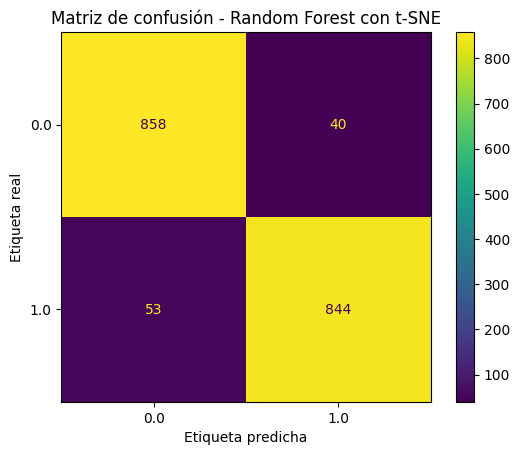

In [45]:
# Fijamos una semilla para que el resultado sea reproducible
semilla = 42
np.random.seed(semilla)

# Recuperamos la partición original:
# en df_tsne, primero están los registros de train y después los de test
n_train = len(X_train_scaled)

X_train_tsne = df_tsne.iloc[:n_train][['tSNE1', 'tSNE2']]
X_test_tsne = df_tsne.iloc[n_train:][['tSNE1', 'tSNE2']]

y_train_tsne = df_tsne.iloc[:n_train]['label']
y_test_tsne = df_tsne.iloc[n_train:]['label']

# Entrenar un modelo de clasificación Random Forest
clf_tsne = RandomForestClassifier(
    n_estimators=100,      # número de árboles
    random_state=semilla,
    max_depth=5,           # profundidad máxima
    min_samples_leaf=5,    # mínimo de muestras en cada hoja
    n_jobs=1               # un solo hilo para mayor reproducibilidad
)

clf_tsne.fit(X_train_tsne, y_train_tsne)

# Predecir y evaluar el modelo
y_train_pred_tsne = clf_tsne.predict(X_train_tsne)
y_test_pred_tsne = clf_tsne.predict(X_test_tsne)

print("Accuracy en entrenamiento con t-SNE:", round(accuracy_score(y_train_tsne, y_train_pred_tsne), 4))
print("Accuracy en test con t-SNE:", round(accuracy_score(y_test_tsne, y_test_pred_tsne), 4))

print("\nMatriz de confusión en test:")
cm_tsne = confusion_matrix(y_test_tsne, y_test_pred_tsne)
print(cm_tsne)

print("\nReporte de clasificación en test:")
print(classification_report(y_test_tsne, y_test_pred_tsne, zero_division=0))

# Representar matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tsne,
    display_labels=clf_tsne.classes_
)

disp.plot(values_format='d')
plt.title('Matriz de confusión - Random Forest con t-SNE')
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta real')
plt.show()


#### ¿Se puede utilizar la reducción de dimensinalidad obtenida por t-SNE para entrenar un algoritmo de clasificación?

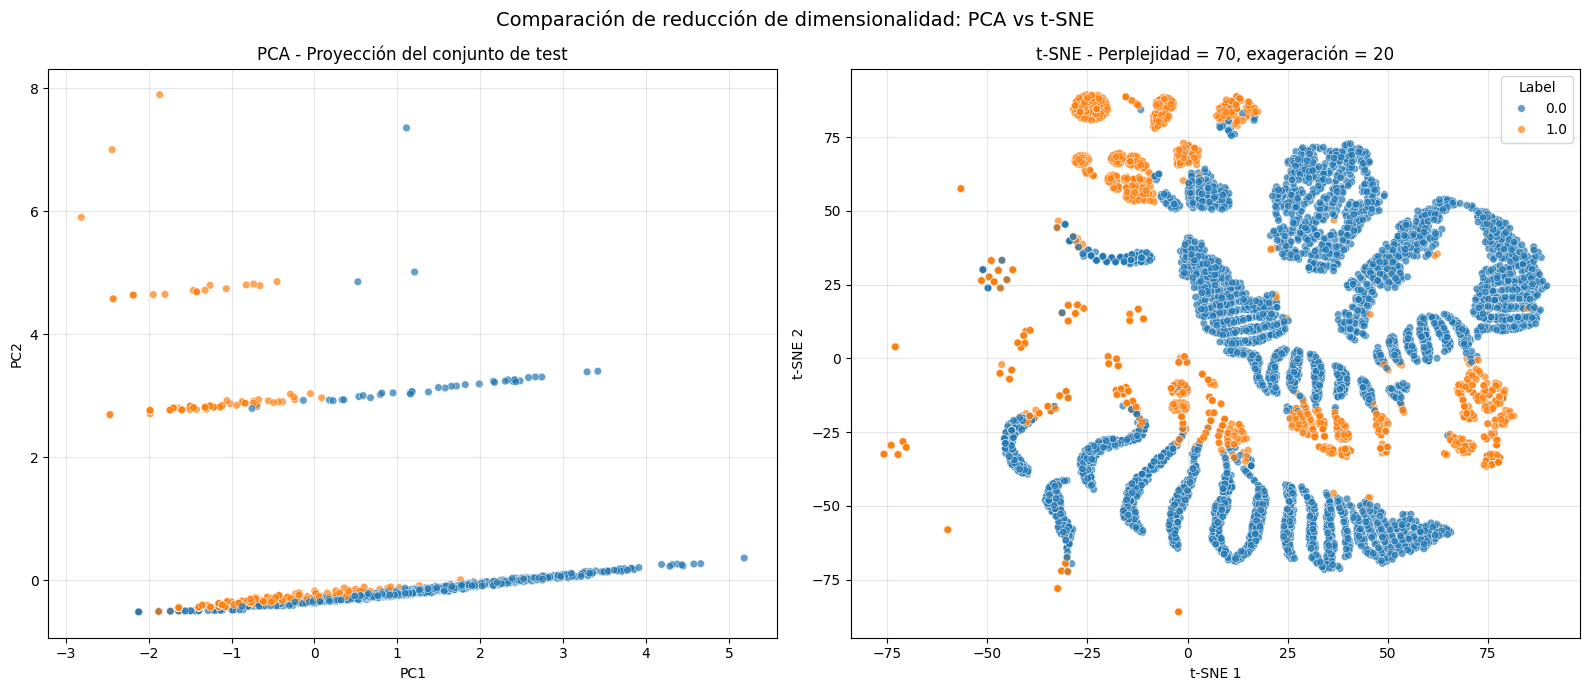

In [46]:
# Comparación visual entre PCA y t-SNE

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA sobre test
sns.scatterplot(
    data=df_test_pca,
    x='PC1',
    y='PC2',
    hue='label',
    alpha=0.7,
    s=30,
    ax=axes[0],
    legend=False
)

axes[0].set_title('PCA - Proyección del conjunto de test')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)

# t-SNE sobre conjunto completo preprocesado
sns.scatterplot(
    data=df_tsne,
    x='tSNE1',
    y='tSNE2',
    hue='label',
    alpha=0.7,
    s=30,
    ax=axes[1]
)

axes[1].set_title(f't-SNE - Perplejidad = {perplejidad}, exageración = {exageracion}')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)
axes[1].legend(title='Label')

plt.suptitle('Comparación de reducción de dimensionalidad: PCA vs t-SNE', fontsize=14)
plt.tight_layout()
plt.show()

En este caso concreto hemos podido utilizar la reducción de dimensionalidad obtenida mediante t-SNE para entrenar un algoritmo de clasificación, sin embargo no es recomendable hacerlo, ya que t-SNE transforma el espacio original de características en una representación bidimensional que intenta preservar las relaciones locales entre observaciones. Entonces, si aparecieran agrupaciones diferenciadas por clase, un clasificador podría aprovechar esa estructura para separar las etiquetas.

Usando t-SNE hemos entrenado un modelo Random Forest obteniendo un rendimiento muy elevado. El modelo obtiene una accuracy de  0.9638 en entrenamiento y de 0.9482 en test. No observamos indicios claros de sobreajuste al ser pequeña la diferencia entre ambas métricas. Por tanto, parece que la separación obtenida es útil para el modelo de clasificación.

Si nos fijamos en la matriz de confusión, vemos que en el conjunto de test, el modelo clasifica correctamente 858 registros de la clase 0 y 844 registros de la clase 1. Se producen 40 falsos positivos, es decir, registros reales de la clase 0 clasificados como clase 1, y 53 falsos negativos, registros reales de la clase 1 clasificados como clase 0. Por tanto, parece que el modelo no muestra un sesgo fuerte hacia ninguna de las dos clases. Estos resultados equilibrados siguen viendose en el reporte realizado con distintas métricas (accuraccy, F1-Score, recall).

En resumen, t-SNE parece ofrecer un rendimiento muy similar a PCA. Con PCA obtuvimos una accuracy en test de 0.9475, mientras que con t-SNE se alcanza una accuracy de 0.9482. Aunque, en la visualización de t-SNE podemos ver una separación más clara entre regiones dominadas por cada clase.

No obstante, debe tenerse en cuenta una limitación importante. El métdodo t-SNE no está diseñado principalmente como una transformación para modelos predictivos, sino como una técnica de visualización exploratoria. A diferencia de PCA, t-SNE no proporciona una transformación lineal sencilla y estable que pueda aplicarse directamente a nuevos datos. Por ello, aunque en este análisis la clasificación sobre la representación t-SNE obtiene buenos resultados, esta evaluación debe interpretarse como una medida exploratoria de la separabilidad de las clases en el espacio proyectado. A esto se suma que, al haber hecho esta transformación antes de separar en conjunto de entrenamiento y evaluación, hemos introducido fuga de información de el modelo, ya que hemos usado información del conjunto de test durante el preprocesado.

En conclusión, t-SNE es útil para visualizar. La técnica permite observar una separación más clara entre clases que PCA y proporciona un espacio bidimensional donde el Random Forest alcanza un rendimiento muy alto. Sin embargo, para un sistema predictivo generalizable es mejor utilizar transformaciones aplicables a nuevos datos, como PCA, o entrenar el clasificador directamente sobre las variables originales estandarizadas.


## Declaración de uso de IA

Durante la elaboración de esta tarea se han utilizado herramientas de IA, en concreto ChatGPT y Gemini.

ChatGPT se ha usado de manera asistencial para comentar dudas sobre los planteamientos realizados, ayudar con la redacción y valorar enfoques. En menor medida también se ha empleado para la elaboración de código y corrección bugs.

Otro uso de chatGPT ha sido dar una orientación inicial del código para dar unas bases sobre las que partir.

Gemini se ha usado fundamentalmente en el entorno de Collab para el autocompletado de código y la corrección de bugs.